# Perception Driven Speed Policy

<img src="https://drive.google.com/uc?export=view&id=1u71bvuqnuzD8EgT6Jqq6frWwM7W1PnHP" width="1000">


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from pathlib import Path
from matplotlib.patches import Rectangle, Patch
from collections import deque

### Connections

In [2]:
import os
from google.colab import drive, userdata
from pathlib import Path

**Connect to Google Drive**

In [4]:
# Connect to Google Drive
if not Path("/content/drive").exists():
  drive.mount("/content/drive")

# Update 'base_dir' with the path to your private workspace on Google Drive
base_dir = Path("/content/drive/MyDrive/00_Workspace")

if not base_dir.exists():
  raise FileNotFoundError(f"Base directory {base_dir} does not exist")

Mounted at /content/drive


**Connect to Foxglove**

In [5]:
# Install foxflow inside the Colab runtime
!pip install -qq git+https://github.com/william-mx/foxflow.git@dev >/dev/null 2>&1
# !pip install -qq foxflow >/dev/null 2>&1

# Import the main reader class that talks to the Foxglove API
from foxflow.reader import BagfileReader

# Load your Foxglove API key from Colab secrets (userdata)
# You need to store FOXGLOVE_KEY in Colab: Runtime → Secrets → Add new
API_KEY = userdata.get('FOXGLOVE_KEY')

# Create a reader instance
# This object will handle authentication and allow us to stream bagfiles
r = BagfileReader(API_KEY)

### Utils

In [9]:
def plot_detections_height(detections, labels: list[str] | None = None, ax=None):
    """
    Parameters:
    - detections: list[list[Detection2DResult]] — one list per frame
    - labels: list of label strings to plot (if None, plots all)
    - ax: optional matplotlib axis to plot into
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))

    points = [
        (i, det.label, det.height)
        for i, frame in enumerate(detections)
        for det in frame
    ]

    df = pd.DataFrame(points, columns=["frame", "label", "height"])

    if labels is not None:
        df = df[df["label"].isin(labels)]

    unique_labels = df["label"].unique()
    colors = plt.cm.tab10.colors
    color_map = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}

    for label, group in df.groupby("label"):
        ax.scatter(group["frame"], group["height"], label=label,
                   color=color_map[label], marker='.', s=30)

    ax.set_ylabel("Height")
    ax.set_title("Detection Height Over Frames")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    if ax is None:
        plt.tight_layout()
        plt.show()


def plot_speed_profile(speed_profile, speed_predictions=None, ax=None):
    """
    Parameters:
    - speed_profile: list of ground truth speed values
    - speed_predictions: optional list of predicted speed values
    - ax: optional matplotlib axis to plot into
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 3))

    ax.plot(speed_profile, drawstyle="steps-post", linewidth=1.5, label="Ground Truth")
    if speed_predictions is not None:
        ax.plot(speed_predictions, drawstyle="steps-post", linewidth=1.5,
                label="Prediction", linestyle="--")
        ax.legend()

    ax.set_xlabel("Frame")
    ax.set_ylabel("Speed")
    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    if ax is None:
        plt.tight_layout()
        plt.show()


def plot_detections_and_speed(detections, speed_profile, labels: list[str] | None = None, speed_predictions=None):
    """
    Combined plot of detection heights and speed profile.
    """
    fig, (ax_height, ax_speed) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                               gridspec_kw={"height_ratios": [3, 1]})

    plot_detections_height(detections, labels=labels, ax=ax_height)
    plot_speed_profile(speed_profile, speed_predictions=speed_predictions, ax=ax_speed)

    plt.tight_layout()
    plt.show()

### Load Data

In [11]:
from foxflow.utils import sync_dataframes

# Select recording
df_info = r.select_recording_by_name('speed_sign_yolo')

# Load yolo detection results
df_det, all_detections = r.read_topic('/detections_2d') # list[list[Detection2DResult]]

# Load steering command data
df_cmd = r.read_topic("/rc/ackermann_cmd")

# Synchronize all DataFrames by time
df_det, df_cmd = sync_dataframes(df_det, df_cmd)

# Get ground truth speed values
speed_profile = df_cmd['speed'].values

### Visualize Data

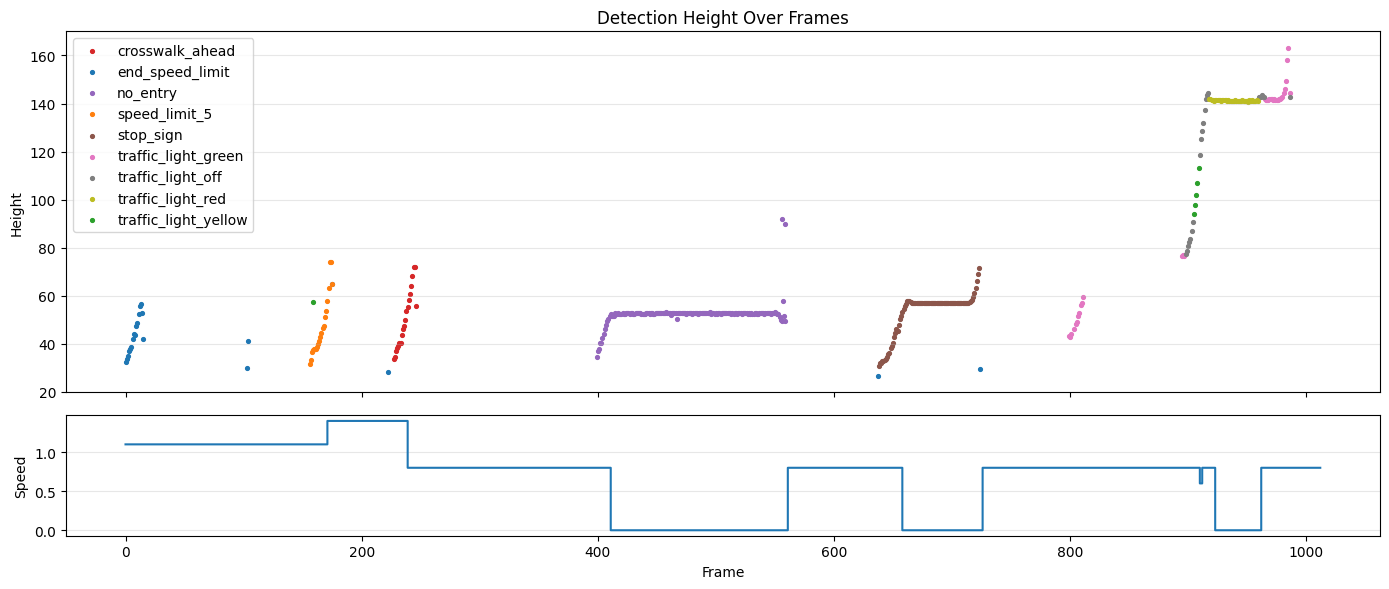

In [12]:
labels=['end_speed_limit', 'speed_limit_5', 'traffic_light_yellow',
        'crosswalk_ahead', 'no_entry', 'stop_sign', 'traffic_light_green',
        'traffic_light_off', 'traffic_light_red']

plot_detections_and_speed(all_detections, speed_profile, labels=labels)

### Run

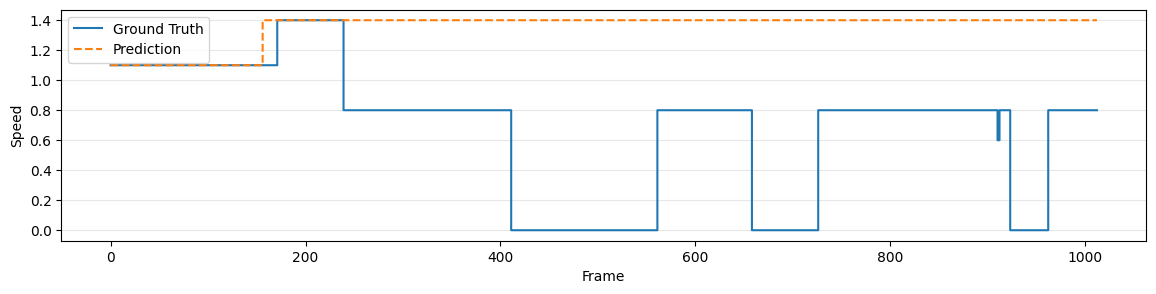

In [18]:
KMH = lambda v: round(v / 3.6, 1)  # km/h → m/s
DEFAULT_SPEED   = 1.1  # cruising speed
ATTENTION_SPEED = 0.8  # caution zones (e.g. crosswalks)

speed_signs = ['crosswalk_ahead', 'end_speed_limit', 'speed_limit_5']

action_signs = ['no_entry', 'stop_sign', 'traffic_light_red', 'traffic_light_yellow']


# Latched speed limits
speed_limit = DEFAULT_SPEED  # persistent regulatory limit
drive_limit = np.nan         # temporary/reactive limit


# Predicted speed per frame
speed_predictions = []

# Iterate over YOLO detections (one per frame)
for i, detections in enumerate(all_detections):

    for d in detections: # list[Detection2DResult]

      # Latch new speed limit when sign is detected
      if d.label == "speed_limit_5" and d.score > 0.0:
          speed_limit = KMH(5)


    speed_predictions.append(speed_limit)


plot_speed_profile(speed_profile, speed_predictions)